# Fuel Price EDA

Exploratory analysis of `data/silver/prices_silver.parquet`.
One row = one unique price-change event, enriched with station details.

Sections: grade coverage, price distributions, brand, station type, price staleness, regional patterns, diesel-petrol spread.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

df = pd.read_parquet("data/silver/prices_silver.parquet")
n_rows, n_stations = len(df), df["node_id"].nunique()
print(f"Rows: {n_rows:,}  |  Unique stations: {n_stations:,}")
df.head(3)

Rows: 29,318  |  Unique stations: 7,969


,node_id,fuel_type,price_ppl,price_change_effective_timestamp,price_last_updated,first_seen_at,pfs_snapshot_used,brand_name,trading_name,postcode,latitude,longitude,city,county,country,is_motorway,is_supermarket,temporary_closure,permanent_closure
0,00008759c79a869b9f324a75570897e003020b74a97383...,B7_STANDARD,171.9,2026-06-19 16:35:01+00:00,2026-06-19 16:12:04.497000+00:00,2026-06-24 15:24:54.918014+00:00,2026-06-24 15:24:54.918014+00:00,TESCO,HARROGATE - PETROL FILLING STATION,HG1 3DW,54.006400,-1.551400,HARROGATE,,ENGLAND,False,False,False,False
1,00008759c79a869b9f324a75570897e003020b74a97383...,E10,146.9,2026-06-22 18:36:43+00:00,2026-06-22 18:36:45.302000+00:00,2026-06-24 15:24:54.918014+00:00,2026-06-24 15:24:54.918014+00:00,TESCO,HARROGATE - PETROL FILLING STATION,HG1 3DW,54.006400,-1.551400,HARROGATE,,ENGLAND,False,False,False,False
2,0001347cef1b054562d9934ab25c6e87de6e2597ca7ccf...,B7_STANDARD,169.9,2026-06-22 12:06:55+00:00,2026-06-22 12:06:55+00:00,2026-06-24 15:24:54.918014+00:00,2026-06-24 15:24:54.918014+00:00,Murco,Checkpoint Service station,SA19 8DT,52.070628,-3.989257,Carmarthenshire,NaN,NaN,False,True,False,False


## 1. Grade coverage

How many stations sell each grade? Establishes what we can actually model.

In [2]:
grade_counts = (
    df.groupby("fuel_type")["node_id"]
    .nunique()
    .sort_values(ascending=False)
    .rename("stations")
    .reset_index()
)
total = df["node_id"].nunique()
grade_counts["pct_of_all_stations"] = (grade_counts["stations"] / total * 100).round(1)
grade_counts

,fuel_type,stations,pct_of_all_stations
0,B7_STANDARD,7863,98.7
1,E10,7787,97.7
2,E5,6201,77.8
3,B7_PREMIUM,4091,51.3
4,HVO,71,0.9
5,B10,59,0.7


## 2. Price distributions

Current E10 and B7_STANDARD price distributions across all stations.
Dashed line = mean, dotted = median.

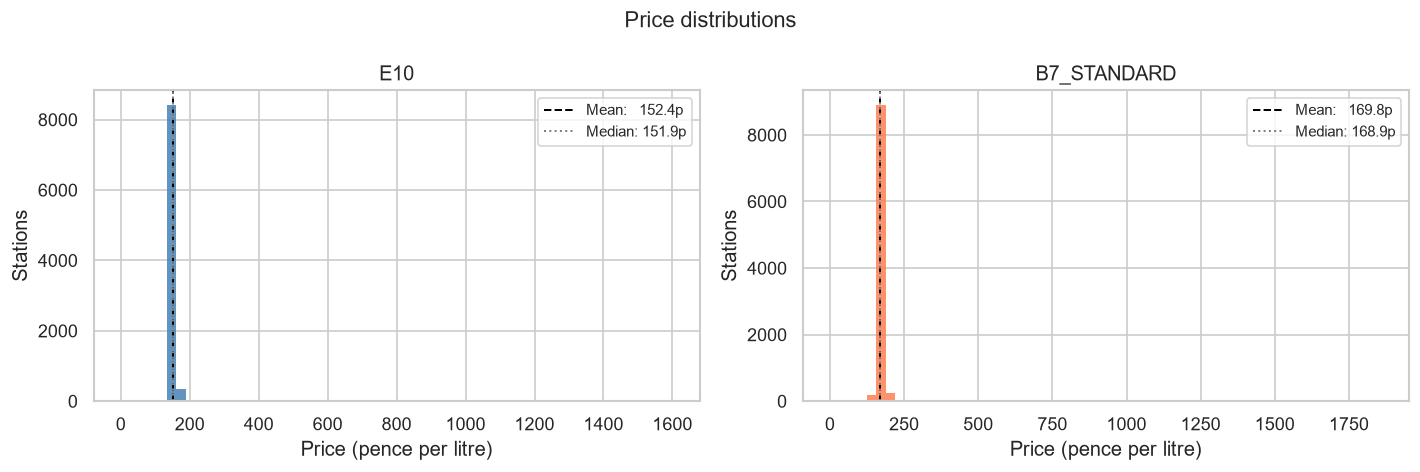


E10
count    8786.0
mean      152.4
std        16.9
min         1.3
25%       148.9
50%       151.9
75%       154.9
max      1599.0

B7_STANDARD
count    9319.00
mean      169.83
std        29.53
min         1.73
25%       165.90
50%       168.90
75%       171.90
max      1859.00


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, grade, color in zip(axes, ["E10", "B7_STANDARD"], ["steelblue", "coral"]):
    data = df.loc[df["fuel_type"] == grade, "price_ppl"].dropna()
    ax.hist(data, bins=60, color=color, edgecolor="none", alpha=0.85)
    mean, median = data.mean(), data.median()
    ax.axvline(mean,   color="black", linestyle="--", lw=1.2, label=f"Mean:   {mean:.1f}p")
    ax.axvline(median, color="grey",  linestyle=":",  lw=1.2, label=f"Median: {median:.1f}p")
    ax.set_title(grade)
    ax.set_xlabel("Price (pence per litre)")
    ax.set_ylabel("Stations")
    ax.legend(fontsize=9)

fig.suptitle("Price distributions", fontsize=13)
plt.tight_layout()
plt.show()

for grade in ["E10", "B7_STANDARD"]:
    print()
    print(grade)
    print(df.loc[df["fuel_type"] == grade, "price_ppl"].describe().round(2).to_string())

## 3. Brand analysis

Median E10 price for the 20 largest brands by station count.
The fair-price model needs to control for brand: supermarkets structurally price below independents.

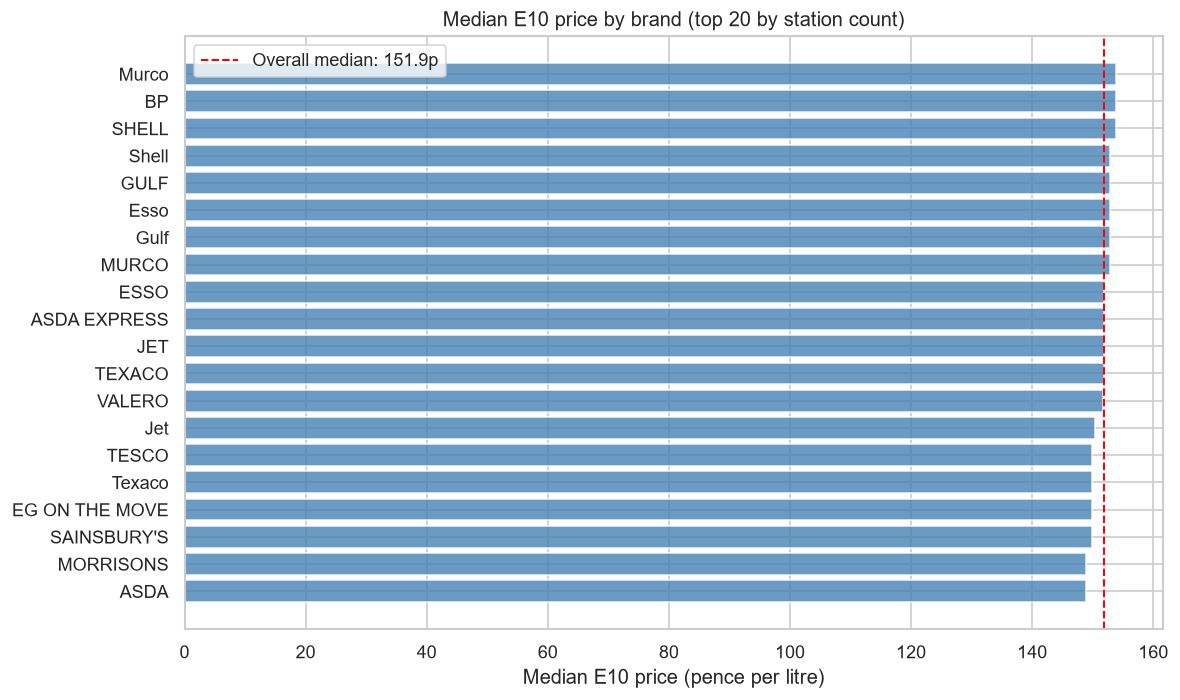

    brand_name  stations  mean  median  std
          ASDA       341 149.3   148.9  3.3
     MORRISONS       410 149.0   148.9  2.8
         TESCO       516 149.6   149.9  3.4
   SAINSBURY'S       381 149.4   149.9  3.3
EG ON THE MOVE       153 150.7   149.9  2.8
        Texaco       209 149.8   149.9 11.3
           Jet        80 151.4   150.4  4.3
        VALERO       106 151.2   151.7  4.2
        TEXACO       364 151.1   151.9  8.6
           JET       275 151.4   151.9  3.2
  ASDA EXPRESS        84 152.1   151.9  3.4
          ESSO      1518 152.5   151.9  5.5
          Esso        87 152.7   152.9  5.7
         Shell        77 153.0   152.9  5.6
          GULF       190 153.5   152.9  4.7
          Gulf       101 154.6   152.9  6.1
         MURCO        54 153.0   152.9  4.6
         Murco        92 154.0   153.9  5.3
         SHELL       876 154.1   153.9  4.9
            BP      1137 154.4   153.9  7.7


In [4]:
e10 = df[df["fuel_type"] == "E10"].dropna(subset=["brand_name"])

brand_stats = (
    e10.groupby("brand_name")["price_ppl"]
    .agg(stations="count", mean="mean", median="median", std="std")
    .reset_index()
)
top20 = brand_stats.nlargest(20, "stations")["brand_name"]
plot_data = brand_stats[brand_stats["brand_name"].isin(top20)].sort_values("median")

overall_median = e10["price_ppl"].median()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_data["brand_name"], plot_data["median"], color="steelblue", alpha=0.8)
ax.axvline(overall_median, color="red", lw=1.2, linestyle="--",
           label=f"Overall median: {overall_median:.1f}p")
ax.set_xlabel("Median E10 price (pence per litre)")
ax.set_title("Median E10 price by brand (top 20 by station count)")
ax.legend()
plt.tight_layout()
plt.show()

print(
    brand_stats.nlargest(20, "stations")
    [["brand_name", "stations", "mean", "median", "std"]]
    .sort_values("median")
    .round(1)
    .to_string(index=False)
)

## 4. Station type: motorway vs supermarket vs independent

Three structurally different groups with different cost bases and customer captivity.
The model must treat them separately.

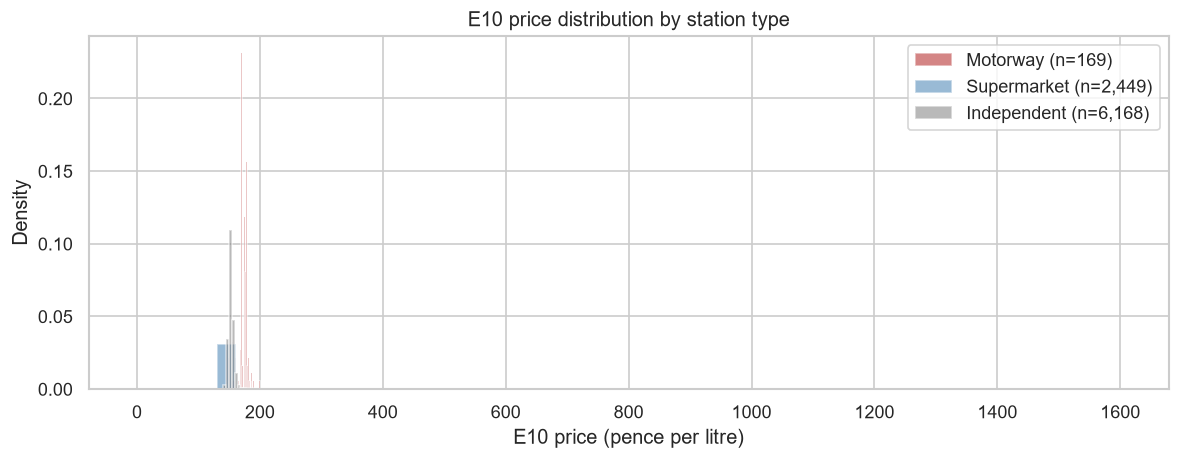

               count    mean    std     min    25%    50%    75%     max
station_type                                                            
Independent   6168.0  152.72   6.43    1.30  149.9  152.9  154.9   239.9
Motorway       169.0  170.75   9.78  144.90  169.9  171.9  178.9   199.9
Supermarket   2449.0  150.33  29.78    1.61  146.9  149.7  151.9  1599.0


In [5]:
e10 = df[df["fuel_type"] == "E10"].copy()

def label_type(row):
    if row["is_motorway"] is True:
        return "Motorway"
    if row["is_supermarket"] is True:
        return "Supermarket"
    return "Independent"

e10["station_type"] = e10.apply(label_type, axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
palette = {"Motorway": "firebrick", "Supermarket": "steelblue", "Independent": "grey"}
for stype, color in palette.items():
    data = e10.loc[e10["station_type"] == stype, "price_ppl"]
    ax.hist(data, bins=50, alpha=0.55,
            label=f"{stype} (n={len(data):,})", color=color, density=True)

ax.set_xlabel("E10 price (pence per litre)")
ax.set_ylabel("Density")
ax.set_title("E10 price distribution by station type")
ax.legend()
plt.tight_layout()
plt.show()

print(e10.groupby("station_type")["price_ppl"].describe().round(2))

## 5. Price staleness

How long ago did each station last change its price?
Stations that rarely change are less useful for modelling price dynamics.

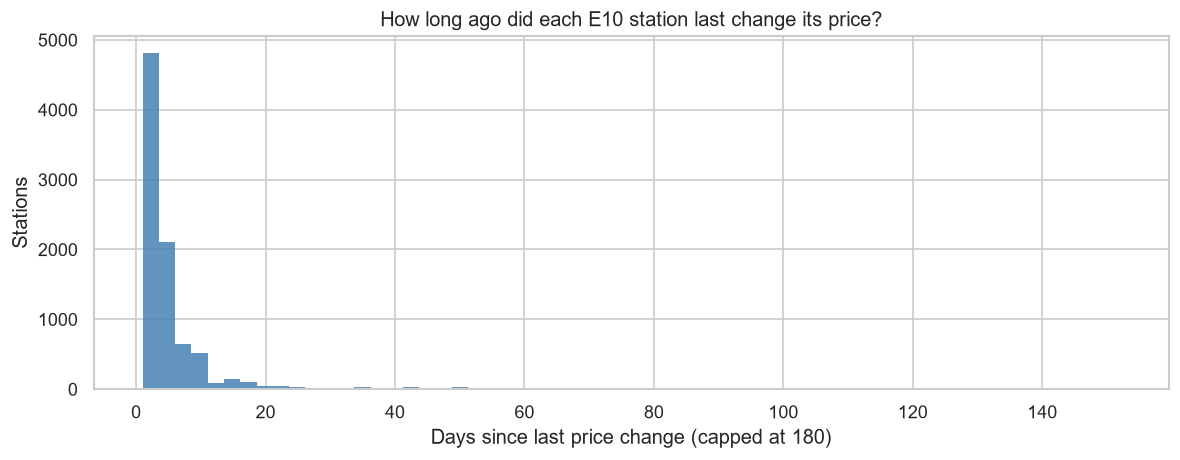

count    8786.0
mean        6.2
std        10.9
min         1.0
25%         2.0
50%         3.0
75%         6.0
max       152.0

Unchanged for >30 days : 234
Unchanged for >7 days  : 1,559
Changed within 24h     : 1,000


In [6]:
now = pd.Timestamp.now(tz="UTC")
e10 = df[df["fuel_type"] == "E10"].copy()
e10["days_since_change"] = (now - e10["price_change_effective_timestamp"]).dt.days

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(e10["days_since_change"].clip(upper=180), bins=60,
        color="steelblue", alpha=0.85, edgecolor="none")
ax.set_xlabel("Days since last price change (capped at 180)")
ax.set_ylabel("Stations")
ax.set_title("How long ago did each E10 station last change its price?")
plt.tight_layout()
plt.show()

d = e10["days_since_change"]
print(d.describe().round(1).to_string())
print()
print(f"Unchanged for >30 days : {(d > 30).sum():,}")
print(f"Unchanged for >7 days  : {(d > 7).sum():,}")
print(f"Changed within 24h     : {(d <= 1).sum():,}")

## 6. Regional patterns

Average E10 price by country. A national model may need country-level fixed effects if regional variation is large.

In [7]:
country_stats = (
    df[df["fuel_type"] == "E10"]
    .dropna(subset=["country"])
    .groupby("country")["price_ppl"]
    .agg(stations="count", mean="mean", median="median", std="std")
    .sort_values("median", ascending=False)
    .reset_index()
)
print("E10 prices by country")
print()
print(country_stats.round(2).to_string(index=False))

E10 prices by country



         country  stations   mean  median   std
        Scotland       215 156.13   154.9  7.28
  UNITED KINGDOM       843 154.01   153.9  4.71
         England      1226 153.93   152.9 42.64
           Wales       139 153.22   152.9  4.32
        SCOTLAND       477 153.30   152.7  6.03
               W         8 152.02   152.4  3.09
               E        76 151.71   151.9  3.52
                       260 151.87   151.9  5.76
         ENGLAND      4400 152.01   151.9  5.78
           WALES       308 151.50   151.3  4.19
              UK         9 149.79   149.9  3.30
               S        12 152.98   149.9  7.14
               N         1 147.90   147.9   NaN
Northern Ireland       194 147.06   145.9  4.06
NORTHERN IRELAND       122 147.12   145.9  4.14


## 7. Diesel-petrol spread (B7_STANDARD minus E10)

For stations selling both grades: how much more expensive is diesel?
A consistent spread suggests a structural premium. Negative values are anomalies.

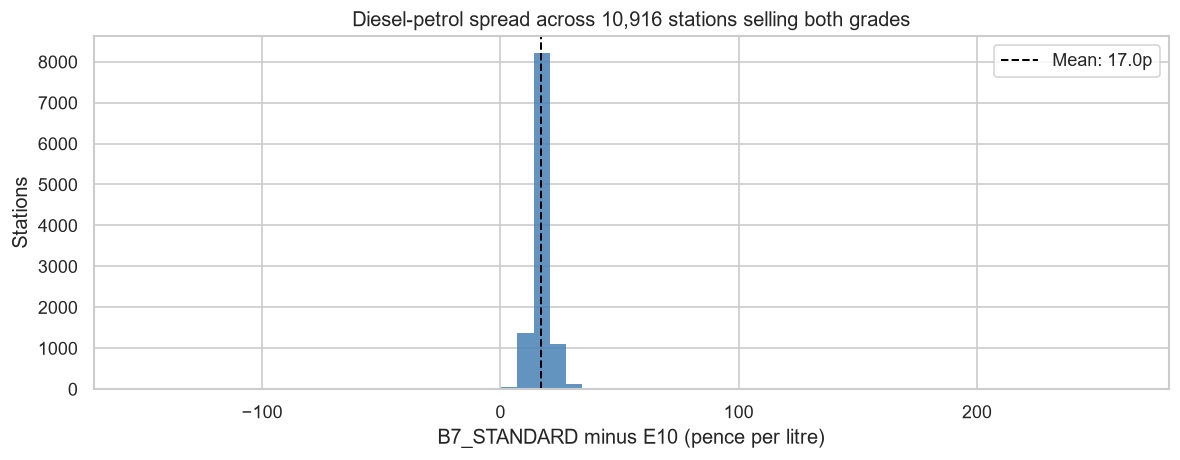

Spread (B7_STANDARD - E10, pence per litre)
count    10916.00
mean        17.02
std          5.03
min       -150.17
25%         15.00
50%         17.00
75%         19.00
max        260.00

Stations where diesel < petrol: 25


In [8]:
e10_p = (
    df[df["fuel_type"] == "E10"][["node_id", "price_ppl"]]
    .rename(columns={"price_ppl": "e10"})
)
b7_p = (
    df[df["fuel_type"] == "B7_STANDARD"][["node_id", "price_ppl"]]
    .rename(columns={"price_ppl": "b7"})
)
spread = e10_p.merge(b7_p, on="node_id")
spread["spread_ppl"] = spread["b7"] - spread["e10"]

mean_spread = spread["spread_ppl"].mean()
n_both = len(spread)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(spread["spread_ppl"], bins=60, color="steelblue", alpha=0.85, edgecolor="none")
ax.axvline(mean_spread, color="black", lw=1.2, linestyle="--",
           label=f"Mean: {mean_spread:.1f}p")
ax.set_xlabel("B7_STANDARD minus E10 (pence per litre)")
ax.set_ylabel("Stations")
ax.set_title(f"Diesel-petrol spread across {n_both:,} stations selling both grades")
ax.legend()
plt.tight_layout()
plt.show()

print("Spread (B7_STANDARD - E10, pence per litre)")
print(spread["spread_ppl"].describe().round(2).to_string())
print()
n_negative = (spread["spread_ppl"] < 0).sum()
print(f"Stations where diesel < petrol: {n_negative}")